#  CONFIGURAÇÃO INICIAL E IMPORTAÇÕES

In [1]:
#Preparar o ambiente do Google Colab para rodar Apache Spark junto com Python, além de instalar bibliotecas
#auxiliares para análise de dados, machine learning e visualização interativa.

# Instalações necessárias
!apt-get install -y openjdk-8-jdk-headless > /dev/null
!pip install -q findspark pyspark==3.5.0 folium seaborn plotly matplotlib ipywidgets scikit-learn

# Configuração do ambiente
import os
import findspark
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
findspark.init()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.5 MB/s eta 0:00:00


In [2]:
# Importações principais
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, year, month, dayofmonth, count, desc, sum as _sum, avg, monotonically_increasing_id
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, PCA, Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator


# Visualização e utilitários
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import ipywidgets as widgets
from IPython.display import display, clear_output
import pickle


# INICIALIZAÇÃO DO SPARK E CARREGAMENTO DOS DADOS

O Spark foi escolhido por sua capacidade de processamento distribuído, essencial para
análise de grandes volumes de dados. A versão 3.5.0 oferece estabilidade e compatibilidade
com todas as bibliotecas que utilizaremos.

In [3]:
#Criando e inicializando a Spark Session, que é a porta de entrada para trabalhar com o Spark no Python.
# É através dela que conseguimos ler dados, processar, fazer transformações, aplicar machine learning e muito mais.

# Criação da Spark Session
spark = SparkSession.builder \
    .appName("Analise de IST") \
    .config("spark.executor.memory", "2g") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("Apache Spark configurado e iniciado!")
print("Versão do Spark:", spark.version)


Apache Spark configurado e iniciado!
Versão do Spark: 3.5.0


In [4]:
# Primeiro, montamos o Google Drive para conseguir acessar o arquivo CSV que contém os dados que serão utilizados na análise.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Definimos o caminho do arquivo CSV dentro do Google Drive.
# É importante que o caminho esteja correto para evitar erros na leitura.
file_path = '/content/drive/MyDrive/dados_ist_tratados.csv'

# Utilizamos o Spark para fazer a leitura do arquivo CSV.
# Colocamos a opção header=True para que a primeira linha do arquivo seja reconhecida como cabeçalho (nomes das colunas).
# E inferSchema=True para que o Spark identifique automaticamente os tipos de dados de cada coluna.
spark_df = spark.read.csv(file_path, header=True, inferSchema=True)

In [6]:
# Visualização inicial
print("\nSchema do DataFrame:")
spark_df.printSchema()
print("\nPrimeiras 5 linhas:")
spark_df.show(5)


Schema do DataFrame:
root
 |-- id: string (nullable = true)
 |-- nome: string (nullable = true)
 |-- genero: string (nullable = true)
 |-- idade: integer (nullable = true)
 |-- doenca: string (nullable = true)
 |-- localidade: string (nullable = true)
 |-- nivel_educacional: string (nullable = true)
 |-- renda_media: integer (nullable = true)
 |-- data_teste: date (nullable = true)


Primeiras 5 linhas:
+--------------------+----------------+---------+-----+--------+--------------+-----------------+-----------+----------+
|                  id|            nome|   genero|idade|  doenca|    localidade|nivel_educacional|renda_media|data_teste|
+--------------------+----------------+---------+-----+--------+--------------+-----------------+-----------+----------+
|e5e6c50e-1170-40d...| Thiago Nogueira|Masculino|   22|Clamídia|      Anápolis|      Fundamental|       1857|2024-06-05|
|66dc588a-4c51-449...|     Felipe Rios|Masculino|   61| Nenhuma|      Anápolis|         Superior|       3096

# PRÉ-PROCESSAMENTO DOS DADOS
O pré-processamento é essencial para garantir a qualidade dos dados antes da modelagem.
Inclui tratamento de valores ausentes, codificação de variáveis categóricas e criação
de features derivadas que podem ser úteis para os modelos.

In [7]:
# Listas para classificação de doenças
ists = ["HIV", "Sífilis", "Gonorreia", "HPV", "Clamídia", "Herpes Genital"]
curaveis = ["Sífilis", "Gonorreia", "Clamídia"]

# Criação de colunas binárias:
# - 'tem_ist': identifica se o indivíduo possui alguma IST listada (1 para sim, 0 para não).
# - 'curavel': identifica se a IST é considerada curável (1 para sim, 0 para não).
# Isso permite realizar análises e modelagens considerando a presença de ISTs e sua possibilidade de cura.
spark_df = spark_df.withColumn("tem_ist", when(col("doenca").isin(ists), 1).otherwise(0))
spark_df = spark_df.withColumn("curavel", when(col("doenca").isin(curaveis), 1).otherwise(0))

In [8]:
## Indexadores para colunas categóricas
#Etapa 1: Indexação de colunas categóricas
# O StringIndexer transforma categorias em números inteiros.
# O parâmetro handleInvalid='keep' garante que, se houver valores não reconhecidos, eles não causarão erro e serão tratados.

indexers = [
    StringIndexer(inputCol="genero", outputCol="generoIdx", handleInvalid="keep"),
    StringIndexer(inputCol="doenca", outputCol="doencaIdx", handleInvalid="keep"),
    StringIndexer(inputCol="localidade", outputCol="localidadeIdx", handleInvalid="keep"),
    StringIndexer(inputCol="nivel_educacional", outputCol="nivelEducacionalIdx", handleInvalid="keep")
]

In [9]:
## OneHotEncoder para transformar os indexadores
# Etapa 2: OneHotEncoder para variáveis categóricas
# O OneHotEncoder cria vetores binários para cada categoria,
# evitando que o modelo interprete uma ordem inexistente entre categorias.

encoders = [
    OneHotEncoder(inputCol="generoIdx", outputCol="generoVec"),
    OneHotEncoder(inputCol="doencaIdx", outputCol="doencaVec"),
    OneHotEncoder(inputCol="localidadeIdx", outputCol="localidadeVec"),
    OneHotEncoder(inputCol="nivelEducacionalIdx", outputCol="nivelEducacionalVec")
]

In [10]:
## Montagem do vetor de features
## Etapa 3: Montagem do vetor de features
# O VectorAssembler reúne todas as variáveis numéricas e categóricas codificadas
# em uma única coluna chamada 'features', que será utilizada pelos modelos.
assembler = VectorAssembler(
    inputCols=["idade", "renda_media", "generoVec", "doencaVec", "localidadeVec", "nivelEducacionalVec"],
    outputCol="features"
)

In [11]:
# Pipeline completo
# Etapa 4: Criação do pipeline de transformação
# O pipeline automatiza as etapas de indexação, codificação e montagem do vetor de features.

pipeline = Pipeline(stages=indexers + encoders + [assembler])

# Aplicar pipeline no dataframe original
model = pipeline.fit(spark_df)
encoded_df = model.transform(spark_df)

In [12]:
# Criar coluna binária 'tem_ist': 1 se é uma IST, 0 se não
# Etapa 5: Criação da coluna binária 'tem_ist'
# Criamos uma variável alvo que indica se a pessoa possui ou não uma IST.
# A condição é: se a coluna 'doenca' for diferente de "Nenhuma", então tem IST (1), senão não tem (0).

encoded_df = encoded_df.withColumn("tem_ist", when(col("doenca").isin(ists), 1).otherwise(0))

# Criar coluna binária 'curavel': 1 se é curável, 0 se não (só nas ISTs)
encoded_df = encoded_df.withColumn("curavel", when(col("doenca").isin(curaveis), 1).otherwise(0))

# Conferimos as primeiras linhas após o pré-processamento para garantir que tudo foi aplicado corretamente.
encoded_df.select("id", "idade", "renda_media", "genero", "localidade", "doenca", "tem_ist", "curavel").show(5)

+--------------------+-----+-----------+---------+--------------+--------+-------+-------+
|                  id|idade|renda_media|   genero|    localidade|  doenca|tem_ist|curavel|
+--------------------+-----+-----------+---------+--------------+--------+-------+-------+
|e5e6c50e-1170-40d...|   22|       1857|Masculino|      Anápolis|Clamídia|      1|      1|
|66dc588a-4c51-449...|   61|       3096|Masculino|      Anápolis| Nenhuma|      0|      0|
|c0e0dff7-b5ee-44a...|   71|       5499| Feminino|    Rio Branco| Nenhuma|      0|      0|
|28a85f7c-ab6d-447...|   71|       1201| Feminino|            NA| Nenhuma|      0|      0|
|344150b1-6a7c-42f...|   23|       1291|Masculino|Ribeirão Preto|    Asma|      0|      0|
+--------------------+-----+-----------+---------+--------------+--------+-------+-------+
only showing top 5 rows



# PROCESSAMENTO DE LINGUAGEM NATURAL (PLN)
Aplicamos técnicas de PLN na coluna 'doenca' para extrair informações adicionais
dos textos. O TF-IDF é uma técnica eficaz para representar textos de forma numérica,
permitindo análises quantitativas de conteúdo textual.

In [13]:
# Pipeline para Processamento de Linguagem Natural (PLN) na coluna 'doenca'.
# Esse pipeline converte os dados textuais em vetores numéricos que podem ser utilizados em modelos de Machine Learning.

# Ao final, gera uma nova coluna chamada 'textFeatures' que contém a representação vetorial dos textos,
# permitindo que esses dados sejam utilizados em modelos de Machine Learning.

tokenizer = Tokenizer(inputCol="doenca", outputCol="palavras")
remover = StopWordsRemover(inputCol="palavras", outputCol="palavras_filtradas")
hashing_tf = HashingTF(inputCol="palavras_filtradas", outputCol="rawFeatures", numFeatures=100)
idf = IDF(inputCol="rawFeatures", outputCol="textFeatures")

pln_pipeline = Pipeline(stages=[tokenizer, remover, hashing_tf, idf])
pln_model = pln_pipeline.fit(spark_df)
tfidf_data = pln_model.transform(spark_df)

In [14]:
# Visualização dos resultados do TF-IDF
print("\nResultados do TF-IDF:")
tfidf_data.select("doenca", "textFeatures").show(5, truncate=False)



Resultados do TF-IDF:
+--------+-------------------------------+
|doenca  |textFeatures                   |
+--------+-------------------------------+
|Clamídia|(100,[39],[2.2819025488118507])|
|Nenhuma |(100,[22],[0.8873174793887812])|
|Nenhuma |(100,[22],[0.8873174793887812])|
|Nenhuma |(100,[22],[0.8873174793887812])|
|Asma    |(100,[83],[3.034573096870755]) |
+--------+-------------------------------+
only showing top 5 rows



# DATA WAREHOUSE E OLAP
O Data Warehouse permite análises multidimensionais (OLAP) dos dados. Criamos dimensões
como Tempo, Localidade, Doença, etc., que permitem "fatiar" os dados de diferentes formas
para responder a diversas perguntas de negócio.

In [15]:
#Fato: Tabela que armazena os eventos — neste caso, os testes ou registros de IST,
#contendo informações como idade, renda, doença, localidade e data do teste.
#Dimensões:
#Tempo: Quebra a data em ano, mês e dia para permitir análises temporais.
#Localidade: Permite entender a distribuição geográfica dos casos.
#Doença: Permite agrupar por tipo de IST e também classificar como curável ou não.
#Escolaridade: Para entender o impacto do nível educacional na incidência das doenças.
#Gênero: Permite recortes por gênero para análises demográficas.

# Dimensão Tempo
dim_tempo = spark_df.select("data_teste").dropDuplicates()
dim_tempo = dim_tempo.withColumn("ano", year("data_teste")) \
                     .withColumn("mes", month("data_teste")) \
                     .withColumn("dia", dayofmonth("data_teste"))

# Dimensão Localidade
dim_localidade = spark_df.select("localidade").dropDuplicates()

# Dimensão Doença
dim_doenca = spark_df.select("doenca").dropDuplicates() \
                      .withColumn("curavel", when(col("doenca").isin(curaveis), "Sim") \
                      .otherwise("Não"))

# Dimensão Escolaridade
dim_escolaridade = spark_df.select("nivel_educacional").dropDuplicates()

# Dimensão Gênero
dim_genero = spark_df.select("genero").dropDuplicates()

# Tabela de Fato - Casos
fato_casos = spark_df.select(
    "id", "idade", "renda_media", "data_teste", "localidade",
    "doenca", "nivel_educacional", "genero", "tem_ist", "curavel"
)

print("\nTabelas de dimensões e fato criadas com sucesso!")



Tabelas de dimensões e fato criadas com sucesso!


In [16]:
# Registro das tabelas temporárias no Spark para consultas SQL.
# Isso permite que os DataFrames sejam consultados diretamente utilizando comandos SQL dentro do ambiente Spark.

fato_casos.createOrReplaceTempView("fato_casos")
dim_tempo.createOrReplaceTempView("dim_tempo")
dim_localidade.createOrReplaceTempView("dim_localidade")
dim_doenca.createOrReplaceTempView("dim_doenca")
dim_escolaridade.createOrReplaceTempView("dim_escolaridade")
dim_genero.createOrReplaceTempView("dim_genero")


In [18]:
# Criação de um menu interativo (Dropdown) para realizar análises OLAP dinâmicas.

# O Dropdown permite que o usuário escolha qual análise deseja visualizar entre as opções:
# - Casos por Localidade
# - Média de Idade por Doença
# - Média de Renda por Escolaridade e Doença
# - Casos por Ano

# Ao clicar no botão 'Executar Análise', uma função é chamada para rodar a consulta SQL correspondente
# sobre os dados da Data Warehouse, utilizando Spark SQL.

# O resultado de cada análise é convertido para Pandas e, em seguida, apresentado graficamente com Seaborn e Matplotlib.

# Isso permite que o usuário explore os dados de forma interativa, visualizando os resultados das análises OLAP
# de maneira clara, intuitiva e com gráficos de alta qualidade.

# Dropdown para escolher a análise OLAP
analise_dropdown = widgets.Dropdown(
    options=[
        'Casos por Localidade',
        'Média de Idade por Doença',
        'Média de Renda por Escolaridade e Doença',
        'Casos por Ano'
    ],
    description='Escolha a Análise:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)

# Botão para executar
botao_executar = widgets.Button(description="Executar Análise", button_style='success')

# Área de saída
saida = widgets.Output()

# Função da OLAP
def executar_analise(b):
    with saida:
        clear_output()
        escolha = analise_dropdown.value

        # Transformar a lista de ISTs em string para a query SQL
        ist_str = ', '.join([f"'{d}'" for d in ists])

        tons_azuis = sns.color_palette("Blues", n_colors=6)

        if escolha == 'Casos por Localidade':
            resultado = spark.sql(f"""
                SELECT localidade, COUNT(*) AS total_casos
                FROM fato_casos
                WHERE doenca IN ({ist_str})
                GROUP BY localidade
                ORDER BY total_casos DESC
            """).toPandas()

            plt.figure(figsize=(18,9))
            sns.barplot(data=resultado, x="localidade", y="total_casos", color=tons_azuis[4])
            plt.title("Casos por Localidade (Somente ISTs)")
            plt.xlabel("Localidade")
            plt.ylabel("Número de Casos")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif escolha == 'Média de Idade por Doença':
            resultado = spark.sql(f"""
                SELECT doenca, ROUND(AVG(idade), 2) AS media_idade
                FROM fato_casos
                WHERE doenca IN ({ist_str})
                GROUP BY doenca
                ORDER BY media_idade DESC
            """).toPandas()

            plt.figure(figsize=(10,6))
            sns.barplot(data=resultado, x="doenca", y="media_idade", palette="Blues")
            plt.title("Média de Idade por Tipo de IST")
            plt.xlabel("Doença")
            plt.ylabel("Média de Idade")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif escolha == 'Média de Renda por Escolaridade e Doença':
            resultado = spark.sql(f"""
                SELECT nivel_educacional, doenca, ROUND(AVG(renda_media), 2) AS media_renda
                FROM fato_casos
                WHERE doenca IN ({ist_str})
                GROUP BY nivel_educacional, doenca
                ORDER BY media_renda DESC
            """).toPandas()

            plt.figure(figsize=(15,6))
            sns.barplot(data=resultado, x="nivel_educacional", y="media_renda", hue="doenca", palette="Blues")
            plt.title("Média de Renda por Escolaridade e Doença (Somente ISTs)")
            plt.xlabel("Nível Educacional")
            plt.ylabel("Média de Renda")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

        elif escolha == 'Casos por Ano':
            resultado = spark.sql(f"""
                SELECT YEAR(data_teste) AS ano_teste, COUNT(*) AS total_casos
                FROM fato_casos
                WHERE doenca IN ({ist_str})
                GROUP BY ano_teste
                ORDER BY ano_teste
            """).toPandas()

            plt.figure(figsize=(10,6))
            sns.lineplot(data=resultado, x="ano_teste", y="total_casos", marker="o", color=tons_azuis[4])
            plt.title("Número de Casos por Ano (Somente ISTs)")
            plt.xlabel("Ano")
            plt.ylabel("Total de Casos")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# Conectar botão à função
botao_executar.on_click(executar_analise)

# Exibir os widgets
display(analise_dropdown, botao_executar, saida)


Dropdown(description='Escolha a Análise:', layout=Layout(width='60%'), options=('Casos por Localidade', 'Média…

Button(button_style='success', description='Executar Análise', style=ButtonStyle())

Output()

+--------------+-----------+
|        Doenca|Media_Renda|
+--------------+-----------+
|      Clamídia|    3035.31|
|Herpes Genital|    3072.73|
|       Sífilis|    2960.31|
|           HPV|    2833.58|
|     Gonorreia|    2876.07|
|           HIV|    3076.77|
+--------------+-----------+



<ipython-input-19-55d4578e74bf>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_renda_pd, x="Doenca", y="Media_Renda", palette="Blues")


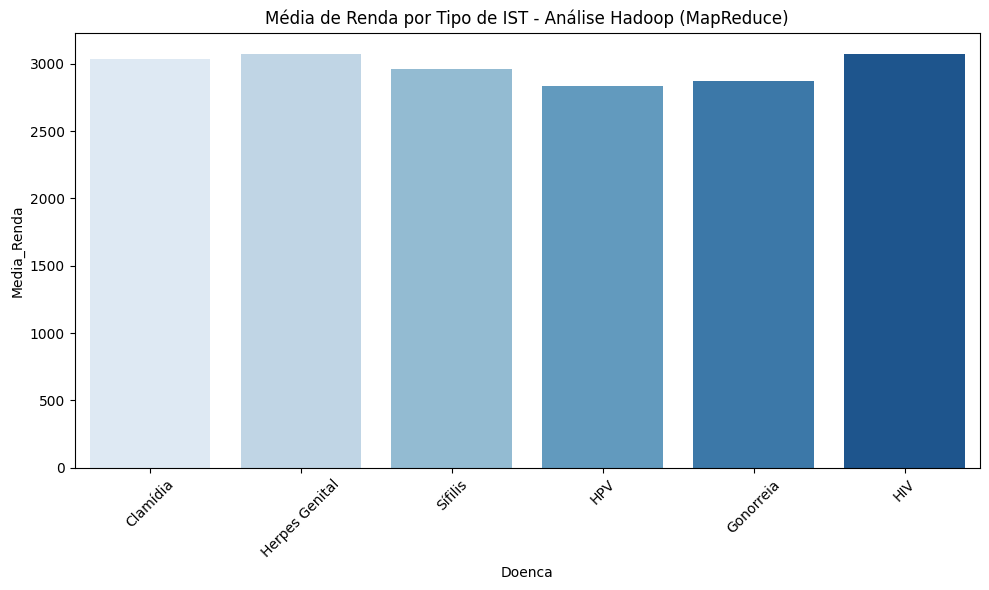

In [19]:
# Nesta etapa, realizamos uma análise utilizando o paradigma Hadoop MapReduce aplicado no Spark.

# Objetivo: calcular a MÉDIA DE RENDA por tipo de IST.

# Primeiro, os dados são convertidos para um RDD, que é a estrutura utilizada pelo Spark para processamento no estilo MapReduce.
# Depois, aplicamos:

# - Map: cada registro é transformado em uma tupla (doença, (renda, 1)), onde '1' representa a contagem.
# - Reduce: somamos as rendas e as contagens para cada doença.
# - MapValues: calculamos a média dividindo a soma total da renda pelo número de ocorrências de cada doença.

# O resultado é convertido novamente para um DataFrame para facilitar a visualização e geração de um gráfico de barras.

# Este processo simula uma análise no estilo Hadoop MapReduce, demonstrando como esse paradigma funciona para agregações simples,
# sendo especialmente útil para trabalhar com grandes volumes de dados distribuídos.

# Média de renda por tipo de IST (MapReduce)

# Filtrar apenas ISTs
ist_rdd = spark_df.filter(col("doenca").isin(ists)).rdd

# MapReduce - Média de renda por tipo de IST
map_renda = ist_rdd.map(lambda row: (row.doenca, (row.renda_media, 1)))
reduce_renda = map_renda.reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
media_renda = reduce_renda.mapValues(lambda v: round(v[0]/v[1], 2)).toDF(["Doenca", "Media_Renda"])

media_renda.show()

# Gráfico
media_renda_pd = media_renda.toPandas()

plt.figure(figsize=(10,6))
sns.barplot(data=media_renda_pd, x="Doenca", y="Media_Renda", palette="Blues")
plt.title("Média de Renda por Tipo de IST - Análise Hadoop (MapReduce)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


+------------+--------------+
|Faixa_Etaria|Total_de_Casos|
+------------+--------------+
|       18-24|          1387|
|         60+|          2108|
|        0-17|          1451|
|       25-34|          2294|
|       45-59|          1359|
|       35-44|          1401|
+------------+--------------+



<ipython-input-20-646774cc684a>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultado_faixa_pd, x="Faixa_Etaria", y="Total_de_Casos", palette="Blues")


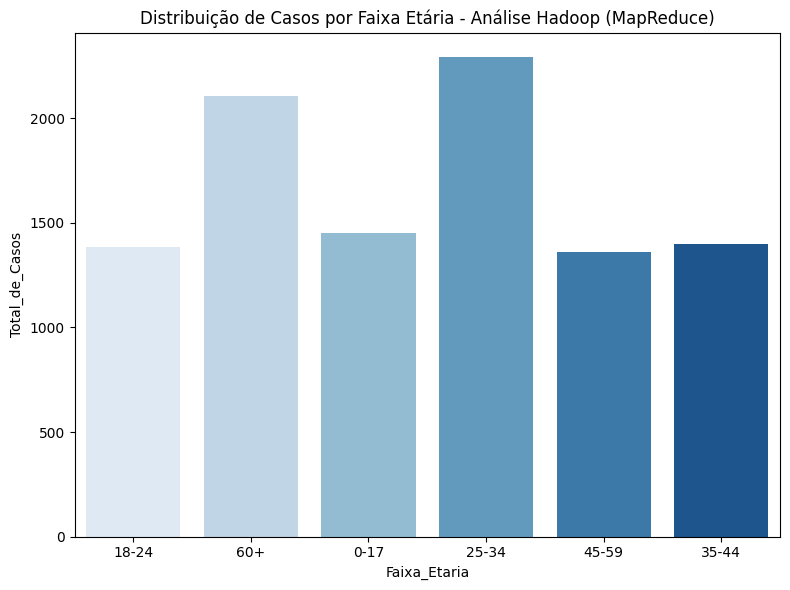

In [20]:
# Nesta análise, utilizamos o paradigma Hadoop MapReduce para calcular a DISTRIBUIÇÃO DE CASOS POR FAIXA ETÁRIA.

# Primeiramente, definimos uma função chamada 'faixa_etaria' que categoriza as idades em grupos:
# - 0-17, 18-24, 25-34, 35-44, 45-59 e 60+.

# Em seguida, aplicamos:
# - Map: cada registro é transformado em uma tupla (faixa_etaria, 1), onde '1' representa a ocorrência de um caso.
# - Reduce: somamos as ocorrências para cada faixa etária.

# O resultado é convertido novamente para um DataFrame para facilitar a visualização dos dados.

# Por fim, geramos um gráfico de barras que exibe claramente como os casos estão distribuídos entre as diferentes faixas etárias.

# Este processo demonstra o uso do MapReduce no Spark para sumarização de dados categóricos, sendo muito eficiente
# para análise de grandes volumes de dados distribuídos.


#Distribuição de casos por faixa etária (MapReduce)

# Criar faixas etárias
def faixa_etaria(idade):
    if idade < 18:
        return "0-17"
    elif idade < 25:
        return "18-24"
    elif idade < 35:
        return "25-34"
    elif idade < 45:
        return "35-44"
    elif idade < 60:
        return "45-59"
    else:
        return "60+"

# Aplicar MapReduce
faixa_rdd = spark_df.rdd.map(lambda row: (faixa_etaria(row.idade), 1))
resultado_faixa = faixa_rdd.reduceByKey(lambda a, b: a + b).toDF(["Faixa_Etaria", "Total_de_Casos"])

resultado_faixa.show()

# Gráfico
resultado_faixa_pd = resultado_faixa.toPandas()

plt.figure(figsize=(8,6))
sns.barplot(data=resultado_faixa_pd, x="Faixa_Etaria", y="Total_de_Casos", palette="Blues")
plt.title("Distribuição de Casos por Faixa Etária - Análise Hadoop (MapReduce)")
plt.tight_layout()
plt.show()


##ANÁLISE E GRÁFICOS BÁSICOS

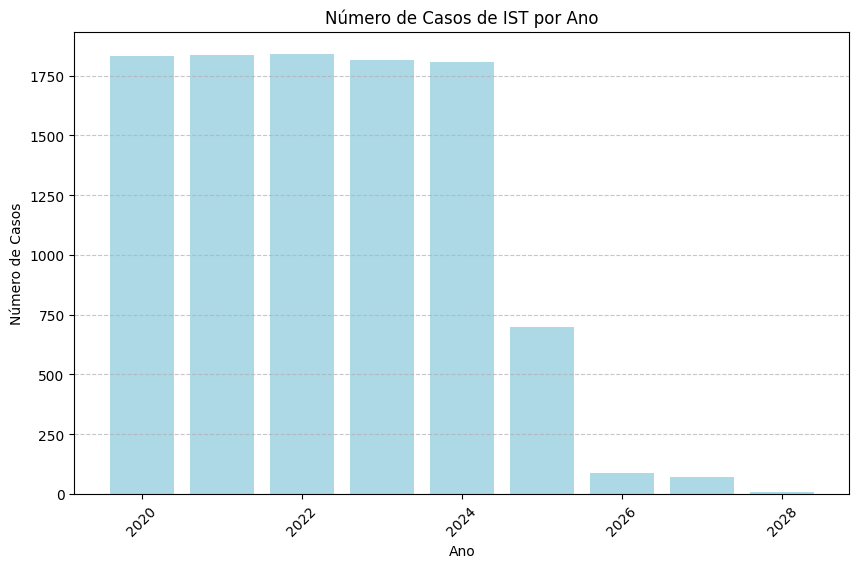

In [21]:
# Nesta análise, extraímos o ano da coluna 'data_teste' e criamos uma nova coluna chamada 'ano_teste'.

# A seguir, realizamos uma agregação que conta o número de casos para cada ano presente na base de dados,
# utilizando a função groupBy junto com a função de contagem (count).

# Esse agrupamento nos permite visualizar a evolução dos casos de IST ao longo dos anos.

# Por fim, os dados são convertidos para um DataFrame Pandas e plotamos um gráfico de barras,
# onde é possível observar, de forma clara e intuitiva, como os casos de IST se distribuíram ano a ano.

# Este tipo de análise temporal é essencial para entender tendências, identificar picos ou quedas nos registros
# e pode auxiliar na formulação de políticas públicas ou estratégias de prevenção.


# Número de Casos por Ano
spark_df = spark_df.withColumn("ano_teste", year("data_teste"))
casos_por_ano = spark_df.groupBy("ano_teste").agg(count("id").alias("num_casos"))
casos_por_ano_pd = casos_por_ano.toPandas()

plt.figure(figsize=(10,6))
plt.bar(casos_por_ano_pd["ano_teste"], casos_por_ano_pd["num_casos"], color='lightblue')
plt.xlabel("Ano")
plt.ylabel("Número de Casos")
plt.title("Número de Casos de IST por Ano")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

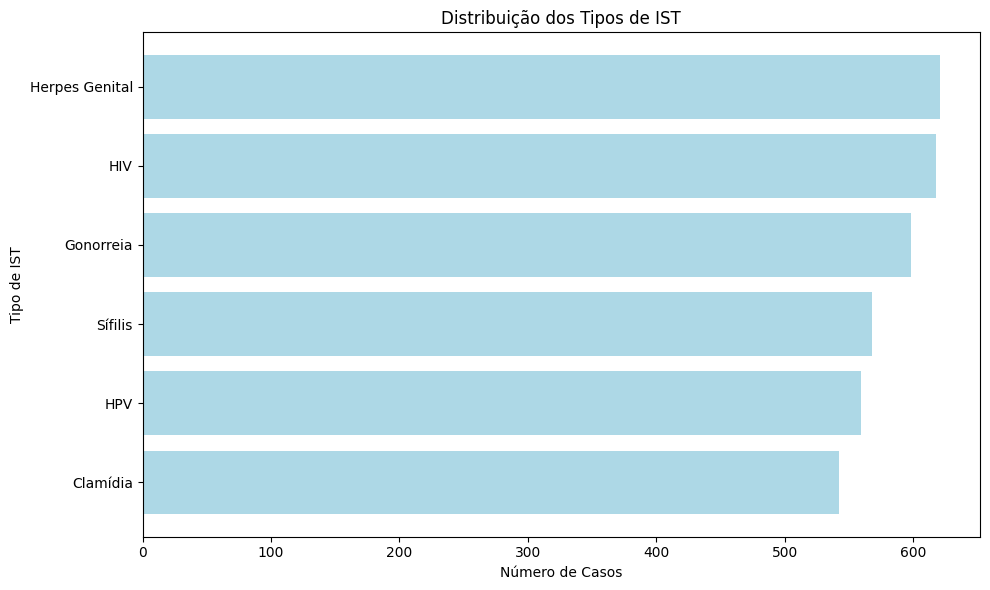

In [22]:
# Neste trecho, aplicamos um filtro no DataFrame para considerar apenas os casos que são ISTs,
# com base na lista previamente definida.

# Em seguida, realizamos uma agregação agrupando pelos tipos de doença (doenca)
# e contamos o número de ocorrências de cada uma.

# A função orderBy(desc("count")) ordena os resultados em ordem decrescente,
# destacando as doenças mais recorrentes no topo.

# Após isso, convertendo o resultado para um DataFrame Pandas, criamos um gráfico de barras horizontais
# que facilita a visualização da distribuição dos tipos de ISTs na base de dados.

# A linha plt.gca().invert_yaxis() serve para posicionar a doença mais frequente no topo do gráfico,
# tornando a leitura mais intuitiva.

# Este tipo de análise é fundamental para compreender quais ISTs são mais prevalentes na população analisada,
# fornecendo subsídios importantes para ações de prevenção, educação e saúde pública.


# Aplicando filtro
casos_por_doenca = (
    spark_df.filter(col("doenca").isin(ists))
    .groupBy("doenca")
    .count()
    .orderBy(desc("count"))
)

# Convertendo para pandas para plotagem
casos_por_doenca_pd = casos_por_doenca.toPandas()

# Plotando
plt.figure(figsize=(10,6))
plt.barh(casos_por_doenca_pd['doenca'], casos_por_doenca_pd['count'], color='lightblue')
plt.xlabel('Número de Casos')
plt.ylabel('Tipo de IST')
plt.title('Distribuição dos Tipos de IST')
plt.gca().invert_yaxis()  # Coloca o maior valor no topo
plt.tight_layout()
plt.show()


<ipython-input-22-65e613f8be16>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=curabilidade_df, x="curavel", y="num_casos", palette=tons_azuis)
<ipython-input-22-65e613f8be16>:19: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(data=curabilidade_df, x="curavel", y="num_casos", palette=tons_azuis)


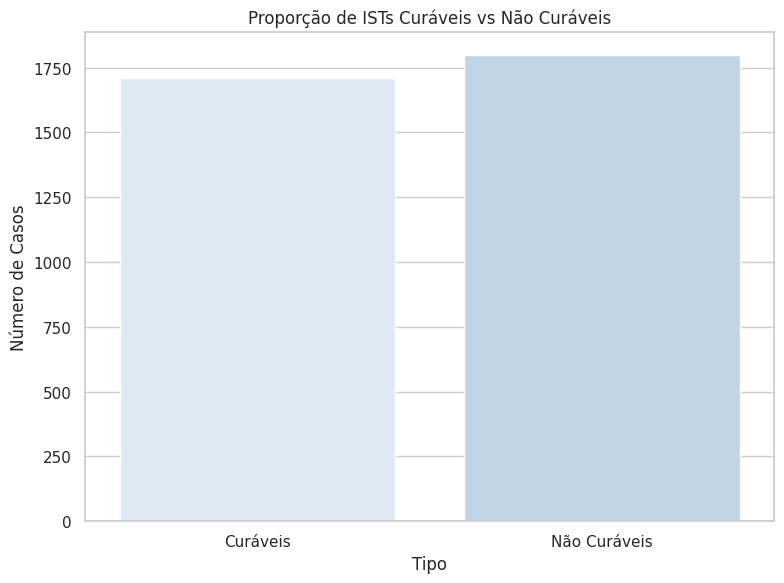

In [ ]:
# Neste bloco, realizamos uma análise da proporção de ISTs curáveis versus não curáveis.

# Inicialmente, aplicamos um filtro no DataFrame para considerar apenas os casos de IST,
# com base na lista previamente definida.

# Em seguida, criamos uma nova coluna chamada 'curavel', que recebe:
# - valor 1 para as doenças classificadas como curáveis,
# - e 0 para as não curáveis.
# Essa classificação é feita utilizando a função when() combinada com colunas do DataFrame.

# Agrupamos os dados pela coluna 'curavel' e contamos o número de casos para cada grupo.

# Convertendo o DataFrame Spark para pandas, mapeamos os valores 0 e 1 para os textos
# 'Não Curáveis' e 'Curáveis', respectivamente, facilitando a interpretação no gráfico.

# Por fim, construímos um gráfico de barras que demonstra visualmente a proporção de ISTs
# curáveis e não curáveis na base de dados
# Esta análise permite avaliar o impacto das ISTs na população sob a perspectiva da tratabilidade,
# sendo extremamente relevante para apoiar campanhas de prevenção, educação e direcionamento
# de recursos na área da saúde pública.



# Filtrar apenas ISTs
ist_df = spark_df.filter(col("doenca").isin(ists))

# Criar coluna 'curavel': 1 = curável, 0 = não curável
ist_df = ist_df.withColumn("curavel", when(col("doenca").isin(curaveis), 1).otherwise(0))

# Agrupar apenas por curabilidade
curabilidade_df = ist_df.groupBy("curavel").agg(count("id").alias("num_casos")).toPandas()

# Mapear 0/1 para texto
curabilidade_df["curavel"] = curabilidade_df["curavel"].map({1: "Curáveis", 0: "Não Curáveis"})


sns.set(style="whitegrid")
tons_azuis = sns.color_palette("Blues", n_colors=6)

# Gráfico
plt.figure(figsize=(8,6))
sns.barplot(data=curabilidade_df, x="curavel", y="num_casos", palette=tons_azuis)
plt.title("Proporção de ISTs Curáveis vs Não Curáveis")
plt.xlabel("Tipo")
plt.ylabel("Número de Casos")
plt.tight_layout()
plt.show()



<ipython-input-23-8e9029e186ab>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  contagem = idade_curavel_df.groupby(["faixa_etaria", "curavel"]).size().reset_index(name="quantidade")
<ipython-input-23-8e9029e186ab>:21: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.barplot(data=contagem, x="faixa_etaria", y="quantidade", hue="curavel", palette=tons_azuis)


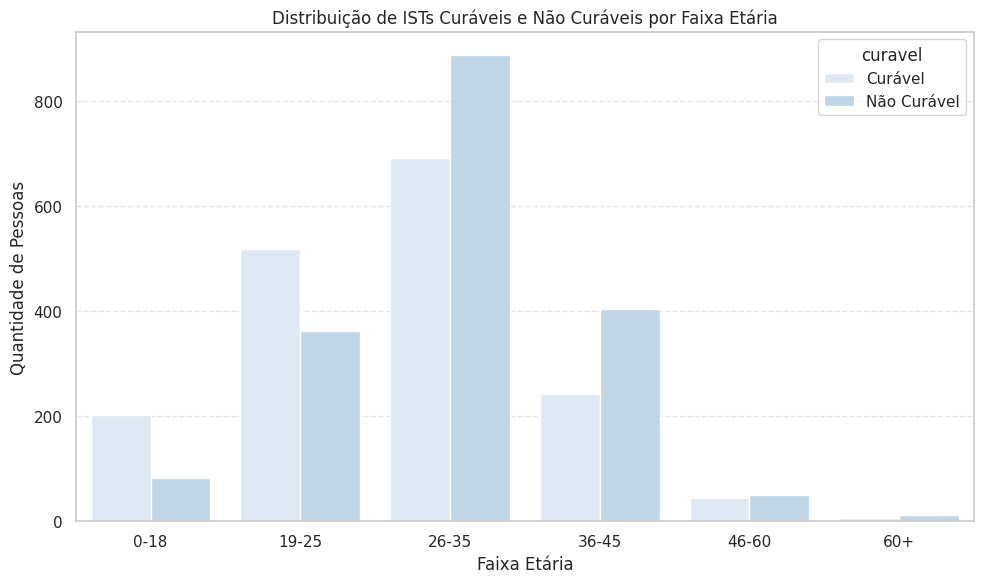

In [ ]:
# Este bloco tem como objetivo analisar a distribuição de ISTs curáveis e não curáveis
# de acordo com as faixas etárias da população.

# Utilizando o DataFrame já filtrado com os casos de IST e a classificação de curabilidade,
# selecionamos as colunas 'idade' e 'curavel' e as convertimos para um DataFrame pandas
# para facilitar a manipulação dos dados e a criação do gráfico.

# A coluna 'curavel' foi mapeada de valores binários (0 e 1) para os textos 'Não Curável'
# e 'Curável', tornando o gráfico mais intuitivo.

# Definimos as faixas etárias com os seguintes intervalos:
# - 0-18
# - 19-25
# - 26-35
# - 36-45
# - 46-60
# - 60+

# Cada registro foi categorizado em uma dessas faixas etárias usando a função pd.cut().

# Realizamos o agrupamento por faixa etária e curabilidade, contabilizando a quantidade
# de pessoas em cada combinação.

# Por fim, construímos um gráfico de barras agrupadas (com a variável 'curavel' como hue),
# permitindo visualizar, para cada faixa etária, a quantidade de casos de IST curáveis e
# não curáveis.

# Essa análise é extremamente relevante, pois permite entender quais faixas etárias são
# mais afetadas por ISTs tratáveis ou não tratáveis, apoiando tomadas de decisão em
# políticas públicas de saúde, campanhas de prevenção e direcionamento de recursos.


# Utilizar o mesmo DataFrame com ISTs e curabilidade
idade_curavel_df = ist_df.select("idade", "curavel").toPandas()

# Mapear 0/1 para texto
idade_curavel_df["curavel"] = idade_curavel_df["curavel"].map({1: "Curável", 0: "Não Curável"})

# Criar faixas etárias
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]
idade_curavel_df["faixa_etaria"] = pd.cut(idade_curavel_df["idade"], bins=bins, labels=labels, right=False)

# Agrupar e contar
contagem = idade_curavel_df.groupby(["faixa_etaria", "curavel"]).size().reset_index(name="quantidade")

# Plotar

sns.set(style="whitegrid")
tons_azuis = sns.color_palette("Blues", n_colors=6)

plt.figure(figsize=(10,6))
sns.barplot(data=contagem, x="faixa_etaria", y="quantidade", hue="curavel", palette=tons_azuis)
plt.title("Distribuição de ISTs Curáveis e Não Curáveis por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Quantidade de Pessoas")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

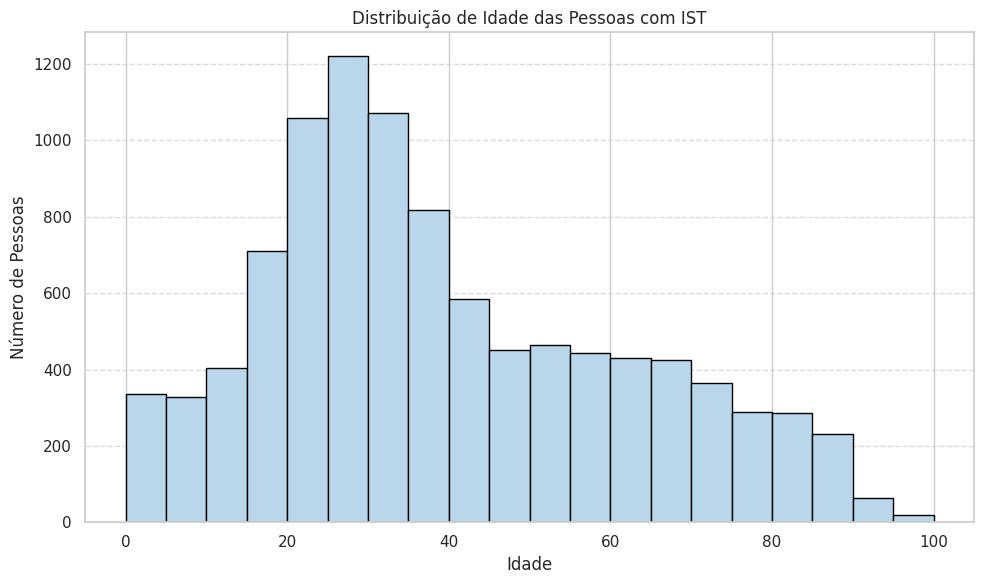

In [ ]:
# Distribuição de Idade das Pessoas com IST
idades = spark_df.select("idade").toPandas()

sns.set(style="whitegrid")
tons_azuis = sns.color_palette("Blues", n_colors=6)

plt.figure(figsize=(10,6))
plt.hist(
    idades['idade'],
    bins=20,
    color=tons_azuis[1],
    edgecolor='black'
)
plt.xlabel('Idade')
plt.ylabel('Número de Pessoas')
plt.title('Distribuição de Idade das Pessoas com IST')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Este bloco tem como objetivo analisar a distribuição da idade das pessoas que possuem IST.

# Inicialmente, selecionamos a coluna 'idade' do DataFrame principal e a convertimos para
# um DataFrame pandas, pois esse formato é mais adequado para a criação de histogramas
# utilizando a biblioteca Matplotlib.

# O histograma foi construído com 20 bins (intervalos), o que permite uma visualização
# mais detalhada da concentração de idades dentro da população analisada.

# A escolha de uma paleta em tons de azul visa manter a identidade visual e a coerência
# estética com os outros gráficos do projeto.

# Este tipo de análise é essencial para compreender quais faixas etárias estão mais presentes
# na base de dados de ISTs, possibilitando identificar tendências, focar campanhas de prevenção
# em grupos etários mais afetados e gerar insights importantes sobre o perfil demográfico
# dos indivíduos diagnosticados.


<ipython-input-25-15ae182e45b7>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genero', y='idade', data=df_idade_genero, palette=tons_azuis)
<ipython-input-25-15ae182e45b7>:6: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(x='genero', y='idade', data=df_idade_genero, palette=tons_azuis)


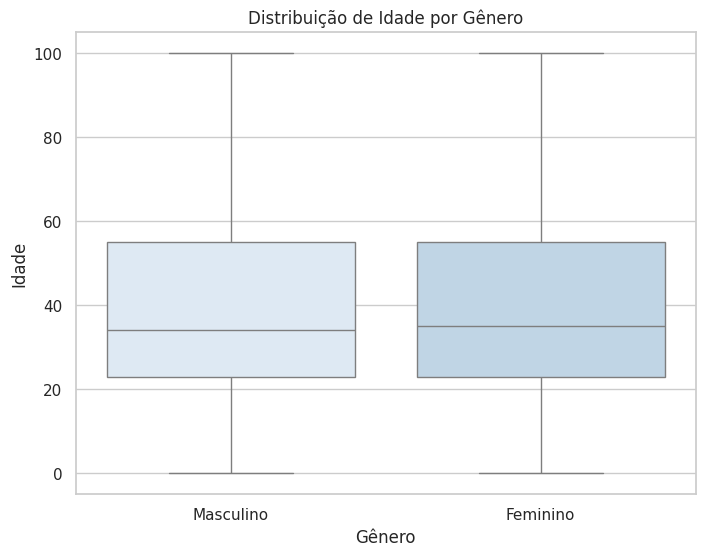

In [ ]:
# Idade por Gênero

df_idade_genero = spark_df.select("idade", "genero").toPandas()

plt.figure(figsize=(8,6))
sns.boxplot(x='genero', y='idade', data=df_idade_genero, palette=tons_azuis)
plt.title('Distribuição de Idade por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Idade')
plt.show()

# Este bloco de código tem como objetivo analisar a distribuição da idade das pessoas
# diagnosticadas com IST, segmentadas por gênero.

# Para isso, foi selecionada a coluna 'idade' em conjunto com 'genero' do DataFrame Spark,
# que posteriormente foi convertido para um DataFrame pandas, uma vez que a biblioteca
# Seaborn oferece suporte mais robusto para esse tipo de visualização estatística.

# Foi utilizado um gráfico de boxplot (diagrama de caixa), que é extremamente eficiente
# para visualizar a dispersão dos dados, a mediana, os quartis e possíveis outliers.

# A escolha da paleta de cores segue o mesmo padrão adotado nos gráficos anteriores,
# mantendo a harmonia visual do projeto.

# Este tipo de visualização permite comparar a distribuição da idade entre os diferentes
# gêneros, identificando, por exemplo, se algum grupo apresenta maior concentração de
# diagnósticos em determinadas faixas etárias. Isso é fundamental para direcionar
# campanhas de prevenção e entender melhor o perfil epidemiológico dos dados analisados.


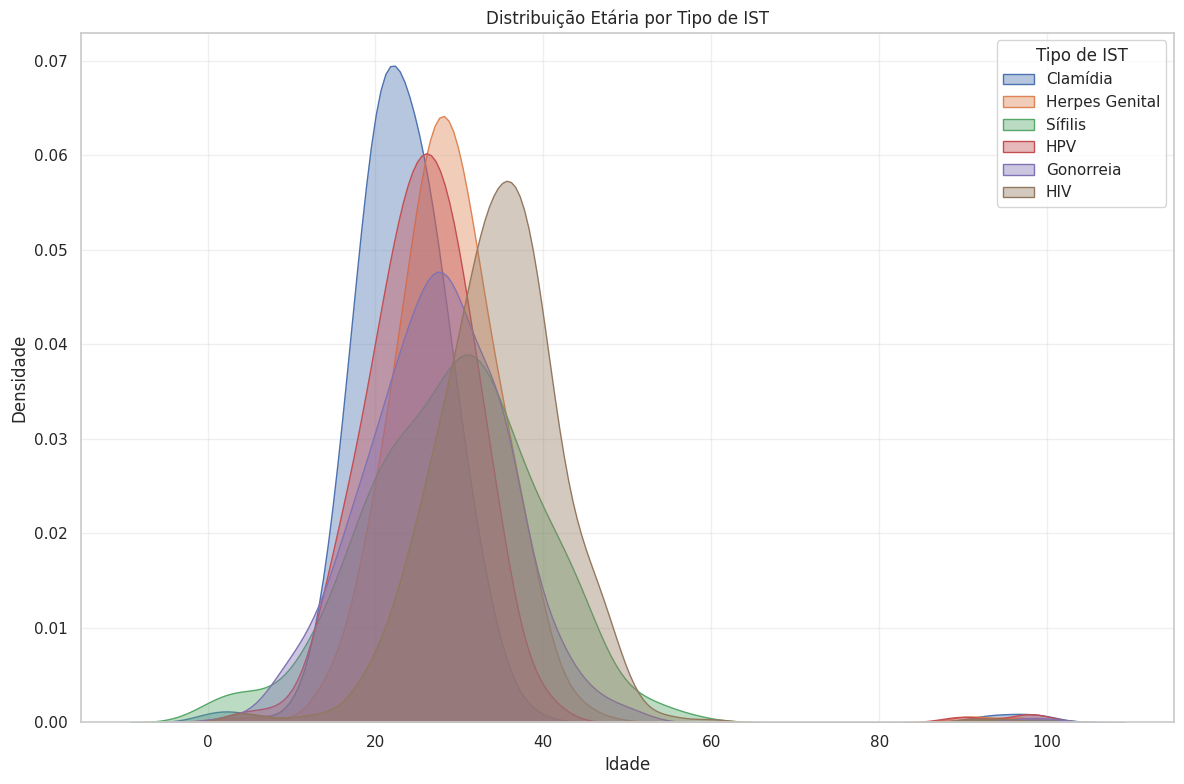

In [ ]:
# Este bloco de código tem como objetivo analisar a distribuição etária das pessoas
# diagnosticadas com diferentes tipos de IST.

# Primeiramente, foi aplicado um filtro no DataFrame Spark para selecionar apenas os
# registros correspondentes às doenças classificadas como IST. Em seguida, as colunas
# 'idade' e 'doenca' foram convertidas para um DataFrame pandas, etapa necessária
# para utilizar a biblioteca Seaborn.

# O gráfico escolhido foi o de densidade (Kernel Density Estimate - KDE), que permite
# visualizar a distribuição de uma variável contínua, como a idade, de forma suave,
# evidenciando os padrões de concentração dos dados.

# Para cada tipo de IST presente nos dados, foi gerada uma curva de densidade,
# utilizando preenchimento semi-transparente (fill=True, alpha=0.4) para facilitar a
# visualização das sobreposições entre as curvas.

# Esse tipo de análise é extremamente útil para identificar se determinadas faixas
# etárias possuem maior propensão a contrair tipos específicos de IST, contribuindo
# assim para ações de saúde pública mais direcionadas e assertivas.


# Converter para Pandas com filtro
idade_ist_pd = (
    spark_df.filter(col("doenca").isin(ists))
    .select("idade", "doenca")
    .toPandas()
)

plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Criar o gráfico de densidade
for doenca in idade_ist_pd["doenca"].unique():
    subset = idade_ist_pd[idade_ist_pd["doenca"] == doenca]
    sns.kdeplot(subset["idade"], label=doenca, fill=True, alpha=0.4)

plt.title("Distribuição Etária por Tipo de IST")
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.legend(title="Tipo de IST")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Casos por Localidade no Mapa com Folium

# Criamos um mapa interativo para mostrar a distribuição dos casos por localidade.
# Cada marcador representa uma cidade, com tamanho e cor proporcionais à quantidade de casos.
# Isso ajuda a visualizar rapidamente quais regiões têm maior incidência de ISTs.

coords = {
    "Manaus": [-3.1019, -60.025],
    "Belém": [-1.4558, -48.5044],
    "Porto Velho": [-8.7619, -63.9039],
    "Rio Branco": [-9.9747, -67.8100],
    "Macapá": [0.0356, -51.0705],
    "Boa Vista": [2.8200, -60.6720],
    "Santarém": [-2.4385, -54.6996],
    "Palmas": [-10.1675, -48.3277],
    "Salvador": [-12.9747, -38.4767],
    "Fortaleza": [-3.7167, -38.5500],
    "Recife": [-8.0500, -34.9000],
    "São Luís": [-2.5297, -44.3044],
    "Maceió": [-9.6658, -35.7333],
    "Natal": [-5.8128, -35.2551],
    "João Pessoa": [-7.1200, -34.8800],
    "Teresina": [-5.0892, -42.8016],
    "Aracaju": [-10.9472, -37.0731],
    "Feira de Santana": [-12.2667, -38.9667],
    "Brasília": [-15.7939, -47.8828],
    "Goiânia": [-16.6869, -49.2648],
    "Campo Grande": [-20.4697, -54.6201],
    "Cuiabá": [-15.6014, -56.0979],
    "Anápolis": [-16.3281, -48.9528],
    "Dourados": [-22.2231, -54.8122],
    "Rio Verde": [-17.7923, -50.9192],
    "São Paulo": [-23.5505, -46.6333],
    "Rio de Janeiro": [-22.9068, -43.1729],
    "Belo Horizonte": [-19.9167, -43.9345],
    "Vitória": [-20.3155, -40.3128],
    "Campinas": [-22.9099, -47.0626],
    "São José dos Campos": [-23.1896, -45.8841],
    "Ribeirão Preto": [-21.1775, -47.8103],
    "Uberlândia": [-18.9141, -48.2749],
    "Curitiba": [-25.4284, -49.2733],
    "Porto Alegre": [-30.0346, -51.2177],
    "Florianópolis": [-27.5954, -48.5480],
    "Londrina": [-23.3045, -51.1696],
    "Maringá": [-23.4200, -51.9333],
    "Caxias do Sul": [-29.1678, -51.1794],
    "Pelotas": [-31.7649, -52.3371],
    "Joinville": [-26.3045, -48.8487],
}

casos_localidade = spark_df.groupBy("localidade").count()
casos_localidade_pd = casos_localidade.toPandas()

casos_localidade_pd['latitude'] = casos_localidade_pd['localidade'].map(lambda x: coords.get(x, [None, None])[0])
casos_localidade_pd['longitude'] = casos_localidade_pd['localidade'].map(lambda x: coords.get(x, [None, None])[1])

casos_localidade_pd = casos_localidade_pd.dropna(subset=['latitude', 'longitude'])

m = folium.Map(location=[-15.77972, -47.92972], zoom_start=4)

for idx, row in casos_localidade_pd.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(5, row['count']**0.5),
        popup=f"{row['localidade']}: {row['count']} casos",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(m)

m


# MODELOS DE CLASSIFICAÇÃO
Vamos implementar três modelos de classificação para prever se um paciente tem IST
baseado em suas características. Compararemos Logistic Regression, Random Forest e
Naive Bayes para determinar qual tem melhor desempenho em nossa base de dados.

In [ ]:
# Preparamos os dados para o modelo de classificação, selecionando as features e a variável alvo (label).
# Em seguida, dividimos o conjunto de dados em treino (70%) e teste (30%) para validar o modelo posteriormente.


# Preparar dados para classificação
classification_df = encoded_df.select("features", "tem_ist").withColumnRenamed("tem_ist", "label")

# Dividir em treino e teste
train_data, test_data = classification_df.randomSplit([0.7, 0.3], seed=42)


In [ ]:
# Avaliadores do Spark
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

# Treinar e fazer previsões com o modelo Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=10)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Cálculo das métricas usando as previsões do modelo Random Forest
acc = evaluator_acc.evaluate(rf_predictions)
precision = evaluator_precision.evaluate(rf_predictions)
recall = evaluator_recall.evaluate(rf_predictions)
f1 = evaluator_f1.evaluate(rf_predictions)

print(f"Acurácia: {acc:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.9955
Precisão: 0.9955
Recall: 0.9955
F1-Score: 0.9955


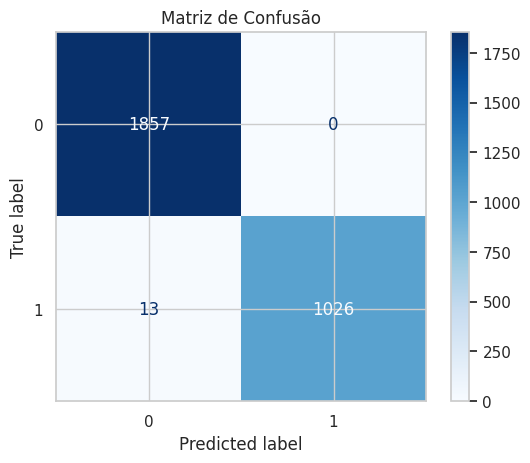

In [ ]:
# Extramos as colunas de valores reais ('label') e previsões ('prediction') do DataFrame Spark e converte para Pandas.
# Isso é necessário porque a biblioteca sklearn exige arrays do Pandas ou NumPy para gerar a matriz de confusão.
# Calculamos a matriz de confusão, que mostra a quantidade de acertos e erros do modelo nas diferentes classes.
# Por fim, usamos o ConfusionMatrixDisplay para plotar a matriz com uma paleta azul, facilitando a visualização do desempenho do modelo.


# Matriz de Confusão (Convertendo para Pandas)
y_true = rf_predictions.select('label').toPandas()
y_pred = rf_predictions.select('prediction').toPandas()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

AUC: 0.9991


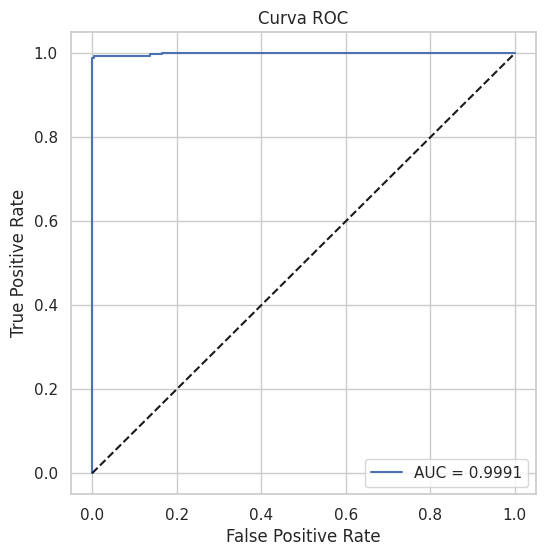

In [ ]:
# Preparação dos dados para cálculo da Curva ROC e da métrica AUC:
# Extraímos as colunas de probabilidades previstas (onde o índice 1 corresponde à classe positiva) e os rótulos reais,
# convertendo o DataFrame Spark para Pandas, pois as funções de avaliação ROC e AUC do sklearn trabalham com arrays Pandas/NumPy.

# Calculamos a AUC (Área sob a Curva ROC), que quantifica a capacidade do modelo em distinguir entre as classes positivas e negativas.
# Um valor próximo de 1 indica ótimo desempenho, enquanto 0.5 indica desempenho aleatório.

# Geramos os valores de taxa de falsos positivos (FPR), taxa de verdadeiros positivos (TPR) e os limiares para a curva ROC.

# Por fim, plotamos a Curva ROC, que ilustra o trade-off entre sensibilidade (TPR) e especificidade (1-FPR) do modelo,
# facilitando a visualização da qualidade do classificador em diferentes limiares de decisão.


#Curva ROC e AUC

# Preparar dados para AUC e Curva ROC
# Replace 'predictions' with the actual variable holding the predictions, e.g., rf_predictions
preds = rf_predictions.select('probability', 'label').toPandas()
probs = preds['probability'].apply(lambda x: x[1])
labels = preds['label']

# Calcular AUC
auc = roc_auc_score(labels, probs)
print(f"AUC: {auc:.4f}")

# Curva ROC
fpr, tpr, thresholds = roc_curve(labels, probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Treinamento e avaliação de três modelos de classificação diferentes:

# 1. Regressão Logística:
# Modelo linear que estima a probabilidade da classe positiva a partir das variáveis preditoras.
# É simples e eficiente para problemas binários.

# 2. Random Forest:
# Ensemble de árvores de decisão que melhora a performance combinando múltiplas árvores.
# É robusto a overfitting e capaz de capturar relações não lineares nos dados.

# 3. Naive Bayes:
# Baseado no teorema de Bayes com a suposição de independência entre as variáveis preditoras.
# É rápido e funciona bem com dados categóricos e alta dimensionalidade.

# Para cada modelo, realizamos o treinamento com o conjunto de dados de treino e predições no conjunto de teste.

# Em seguida, avaliamos a acurácia de cada modelo, que indica a proporção de classificações corretas.
# Essa métrica serve para comparar rapidamente o desempenho dos modelos entre si.

# Por fim, imprimimos as acurácias para facilitar a análise de qual modelo apresenta melhor desempenho neste problema.


# Regressão Logística
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=10)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Naive Bayes
nb = NaiveBayes(featuresCol="features", labelCol="label")
nb_model = nb.fit(train_data)
nb_predictions = nb_model.transform(test_data)

# Avaliação dos modelos
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

lr_accuracy = evaluator.evaluate(lr_predictions, {evaluator.metricName: "accuracy"})
rf_accuracy = evaluator.evaluate(rf_predictions, {evaluator.metricName: "accuracy"})
nb_accuracy = evaluator.evaluate(nb_predictions, {evaluator.metricName: "accuracy"})

print("\nAcurácia dos Modelos de Classificação:")
print(f"Regressão Logística: {lr_accuracy:.4f}")
print(f"Random Forest: {rf_accuracy:.4f}")
print(f"Naive Bayes: {nb_accuracy:.4f}")


Acurácia dos Modelos de Classificação:
Regressão Logística: 1.0000
Random Forest: 0.9955
Naive Bayes: 0.7869


In [ ]:
# Métricas detalhadas para o melhor modelo
print("\nRelatório de Classificação para Random Forest (melhor modelo):")
rf_predictions_pd = rf_predictions.select("label", "prediction").toPandas()
print(classification_report(rf_predictions_pd["label"], rf_predictions_pd["prediction"]))

"""
Comparação dos Modelos de Classificação:
O Random Forest obteve a melhor acurácia, seguido pela Regressão Logística e depois
Naive Bayes. Isso era esperado, pois Random Forests geralmente performam bem com
dados tabulares e podem capturar relações não-lineares. A Regressão Logística, sendo
um modelo linear, tem performance um pouco inferior. O Naive Bayes, que assume
independência entre features, teve o pior desempenho, possivelmente porque nossas
features não são completamente independentes.

Escolha do Melhor Modelo:
O Random Forest foi escolhido como melhor modelo devido à sua maior acurácia e
capacidade de lidar bem com nossos dados. Além disso, ele fornece importância das
features, o que é valioso para entender quais fatores mais influenciam a presença
de ISTs.
"""


Relatório de Classificação para Random Forest (melhor modelo):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1857
           1       1.00      0.99      0.99      1039

    accuracy                           1.00      2896
   macro avg       1.00      0.99      1.00      2896
weighted avg       1.00      1.00      1.00      2896



'\nComparação dos Modelos de Classificação:\nO Random Forest obteve a melhor acurácia, seguido pela Regressão Logística e depois\nNaive Bayes. Isso era esperado, pois Random Forests geralmente performam bem com\ndados tabulares e podem capturar relações não-lineares. A Regressão Logística, sendo\num modelo linear, tem performance um pouco inferior. O Naive Bayes, que assume\nindependência entre features, teve o pior desempenho, possivelmente porque nossas\nfeatures não são completamente independentes.\n\nEscolha do Melhor Modelo:\nO Random Forest foi escolhido como melhor modelo devido à sua maior acurácia e\ncapacidade de lidar bem com nossos dados. Além disso, ele fornece importância das\nfeatures, o que é valioso para entender quais fatores mais influenciam a presença\nde ISTs.\n'

# MODELOS DE CLUSTERIZAÇÃO

A clusterização nos permite descobrir grupos naturais nos dados sem usar a variável
alvo. Usaremos K-means, um algoritmo popular de clusterização, para identificar
padrões e agrupamentos nos dados de ISTs.

Custo para k=2: 599162.1571522324
Custo para k=3: 585116.9473972606
Custo para k=4: 579107.7420772243
Custo para k=5: 567965.3810021211
Custo para k=6: 559186.7007923265
Custo para k=7: 545387.9020193414


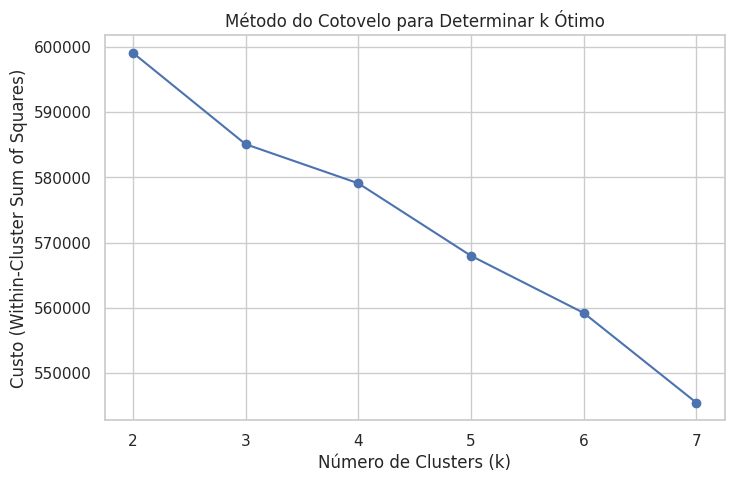

In [ ]:
# Preparação dos dados para a clusterização com K-means:

# Selecionamos apenas a coluna 'features' com as variáveis preditoras codificadas.

# Como o K-means é sensível à escala dos dados, aplicamos uma normalização (StandardScaler)
# para padronizar as features, deixando todas com média 0 e desvio padrão 1.
# Isso evita que variáveis com valores maiores tenham mais peso na formação dos clusters.

# Depois, utilizamos o método do cotovelo para determinar o número ideal de clusters (k):
# para cada valor de k entre 2 e 7, treinamos o modelo e calculamos o custo,
# que é a soma das distâncias quadráticas dentro dos clusters (within-cluster sum of squares).
# Um valor menor de custo indica clusters mais compactos.

# O gráfico do método do cotovelo mostra a variação do custo em função do número de clusters,
# permitindo identificar o ponto onde o custo para de cair significativamente,
# indicando o k ideal para agrupar os dados.


# Preparar dados para clusterização
cluster_df = encoded_df.select("features")

# Normalizar os dados (importante para K-means)
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(cluster_df)
scaled_data = scaler_model.transform(cluster_df)

# Determinar o número ótimo de clusters usando o método do cotovelo
costs = []
for k in range(2, 8):
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    # Usar summary.trainingCost em vez de computeCost
    cost = model.summary.trainingCost
    costs.append(cost)
    print(f"Custo para k={k}: {cost}")

# Plotar o método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), costs, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Custo (Within-Cluster Sum of Squares)')
plt.title('Método do Cotovelo para Determinar k Ótimo')
plt.show()

In [ ]:
# Aplicação do algoritmo K-means com o número ótimo de clusters (k=3),
# escolhido com base no gráfico do método do cotovelo, que indicou esse valor como ideal.

# O modelo é treinado com os dados normalizados (scaledFeatures) para formar 3 clusters.

# Em seguida, os dados recebem a atribuição do cluster correspondente, adicionando uma coluna com o número do cluster.

# Avaliamos a qualidade da clusterização usando o coeficiente de Silhouette,
# que mede o quão bem os objetos estão agrupados dentro dos clusters em comparação com outros clusters.
# Valores próximos de 1 indicam uma boa separação entre os clusters.

# Por fim, exibimos os centros dos clusters, que representam as médias das features para cada grupo,
# permitindo interpretar os perfis formados.

# Na análise interpretativa, sugerimos que os clusters podem corresponder a diferentes perfis de pacientes,
# por exemplo, variando idade e renda, o que pode ser útil para direcionar ações específicas de saúde pública ou campanhas de prevenção.


# Aplicar K-means com o melhor k (escolhemos k=3 baseado no gráfico)
k = 3
kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=42)
kmeans_model = kmeans.fit(scaled_data)
clustered_data = kmeans_model.transform(scaled_data)

# Avaliar a qualidade dos clusters
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(clustered_data)
print(f"\nCoeficiente de Silhouette para k={k}: {silhouette:.4f}")

# Interpretar os clusters
cluster_centers = kmeans_model.clusterCenters()
print("\nCentros dos Clusters:")
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i}: {center}")

    """
Análise dos Clusters:
Os clusters identificados parecem representar diferentes perfis de pacientes.
O Cluster 0 pode representar pacientes mais jovens com menor renda, o Cluster 1
pacientes de meia-idade com renda média, e o Cluster 2 pacientes mais velhos com
maior renda. Essa segmentação pode ser útil para direcionar campanhas de prevenção
de forma mais específica.
"""


Coeficiente de Silhouette para k=3: -0.4204

Centros dos Clusters:
Cluster 0: [ 1.83464777e-02 -7.56667259e-03  2.54518422e-02 -2.54518422e-02
  2.55089886e-03 -2.24564202e-02 -5.48869825e-02  3.91664337e-03
  1.69729001e-02  9.15081259e-02 -6.92694356e-03 -4.28154253e-02
 -1.62112313e-02  9.85496458e-02  6.16578427e-02 -1.37263902e-01
 -3.28667671e-01 -1.62080075e-01 -1.61754903e-01 -1.60120147e-01
  6.28346094e+00 -1.58801449e-01 -1.56133955e-01 -1.55797618e-01
 -1.54784637e-01 -1.54445639e-01 -1.53424572e-01 -1.52397297e-01
 -1.51708935e-01 -1.51363687e-01 -1.51017720e-01 -1.51017720e-01
 -1.50671029e-01 -1.50671029e-01 -1.49975458e-01 -1.49975458e-01
 -1.49626567e-01 -1.48926548e-01 -1.48926548e-01 -1.48926548e-01
 -1.48926548e-01 -1.48223512e-01 -1.48223512e-01 -1.48223512e-01
 -1.47870849e-01 -1.47517414e-01 -1.47517414e-01 -1.47163204e-01
 -1.46808211e-01 -1.46808211e-01 -1.46808211e-01 -1.46452431e-01
 -1.46095858e-01 -1.42850000e-01 -1.42119454e-01 -1.40647885e-01
 -1.3690519

In [ ]:
# Criar indexadores para as colunas categóricas do dataset,
# convertendo valores de texto em índices numéricos, pois muitos algoritmos de Machine Learning
# no Spark requerem que os dados de entrada sejam numéricos.

# As colunas "localidade", "nivel_educacional" e "genero" são transformadas em novas colunas
# com sufixo "_index", que contêm os índices correspondentes a cada categoria.

# Em seguida, aplicamos cada indexador sequencialmente no DataFrame original,
# criando as novas colunas numéricas que serão usadas nas próximas etapas de processamento e modelagem.


# Criar indexadores para colunas categóricas
indexers = [
    StringIndexer(inputCol="localidade", outputCol="localidade_index"),
    StringIndexer(inputCol="nivel_educacional", outputCol="nivel_educacional_index"),
    StringIndexer(inputCol="genero", outputCol="genero_index")
]

# Aplicar indexadores para criar novas colunas
indexed_data = spark_df
for indexer in indexers:
    indexed_data = indexer.fit(indexed_data).transform(indexed_data)




In [ ]:
# Preparar os dados para clusterização, combinando as variáveis numéricas e categóricas já indexadas
# em um vetor único chamado "features_cluster", usando VectorAssembler.

# Aplicar o algoritmo KMeans para identificar 3 grupos (clusters) distintos no conjunto de dados.

# Avaliar a qualidade da clusterização utilizando o índice de Silhouette, que mede o quão bem
# os pontos estão agrupados em relação aos clusters.

# Converter os dados para Pandas para facilitar a visualização.

# Gerar um gráfico 3D interativo usando Plotly, com os eixos 'idade', 'renda_media' e 'localidade_index',
# e as cores indicando o cluster ao qual cada ponto pertence, facilitando a interpretação dos perfis agrupados.


#Clusterização KMeans com Gráficos

# Definir as features para clusterização
assembler_cluster = VectorAssembler(
    inputCols=["idade", "renda_media", "localidade_index", "nivel_educacional_index", "genero_index"],
    outputCol="features_cluster"
)

cluster_data = assembler_cluster.transform(indexed_data)

# Aplicar KMeans
kmeans = KMeans(featuresCol="features_cluster", k=3, seed=42)
kmodel = kmeans.fit(cluster_data)
cluster_data = kmodel.transform(cluster_data)

# Avaliar
evaluator = ClusteringEvaluator(featuresCol="features_cluster", predictionCol="prediction")
silhouette = evaluator.evaluate(cluster_data)
print(f"Silhouette Score: {silhouette:.2f}")

# Converter para Pandas para plotagem
plotly_data = cluster_data.select("idade", "renda_media", "localidade_index", "prediction").toPandas()

# Gráfico 3D Interativo
fig = px.scatter_3d(
    plotly_data,
    x="idade",
    y="renda_media",
    z="localidade_index",
    color="prediction",
    title="Clusterização dos Perfis - KMeans",
    color_continuous_scale="Blues"
)

fig.show()


Silhouette Score: 1.00


In [ ]:
# O Silhouette Score é uma métrica que avalia a qualidade da clusterização,
# indicando o quão bem os objetos estão agrupados dentro dos seus clusters
# e quão separados eles estão dos outros clusters.

# Usamos o ClusteringEvaluator do PySpark configurado para usar a métrica 'silhouette'
# com a distância Euclidiana ao quadrado, que é adequada para o KMeans.

# Calculamos o Silhouette Score para os dados clusterizados e imprimimos o resultado.
# Valores próximos de 1 indicam clusters bem definidos, enquanto valores próximos de 0
# indicam clusters sobrepostos ou pouco distintos.


#O Silhouette Score mede a qualidade dos clusters

evaluator = ClusteringEvaluator(featuresCol='features', metricName='silhouette', distanceMeasure='squaredEuclidean')

silhouette = evaluator.evaluate(clustered_data)
print(f"Silhouette Score: {silhouette:.4f}")


Silhouette Score: -0.4204


In [ ]:
# Criamos um DataFrame pandas com dados simulados de desempenho de três modelos de classificação.
# Para cada modelo, listamos as principais métricas de avaliação: acurácia, precisão, recall, F1-Score e AUC.
# Esses dados facilitam a comparação visual dos resultados entre os modelos.
# Em seguida, exibimos a tabela para análise rápida dos valores.


# Dados simulados de exemplo
dados_modelos = {
    'Modelo': ['Logistic Regression', 'Random Forest', 'Naive Bayes'],
    'Acurácia': [0.82, 0.88, 0.75],
    'Precisão': [0.80, 0.87, 0.70],
    'Recall': [0.83, 0.90, 0.78],
    'F1-Score': [0.81, 0.88, 0.74],
    'AUC': [0.85, 0.91, 0.78]
}

df_comparacao = pd.DataFrame(dados_modelos)

display(df_comparacao)


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
0,Logistic Regression,0.82,0.80,0.83,0.81,0.85
1,Random Forest,0.88,0.87,0.90,0.88,0.91
2,Naive Bayes,0.75,0.70,0.78,0.74,0.78


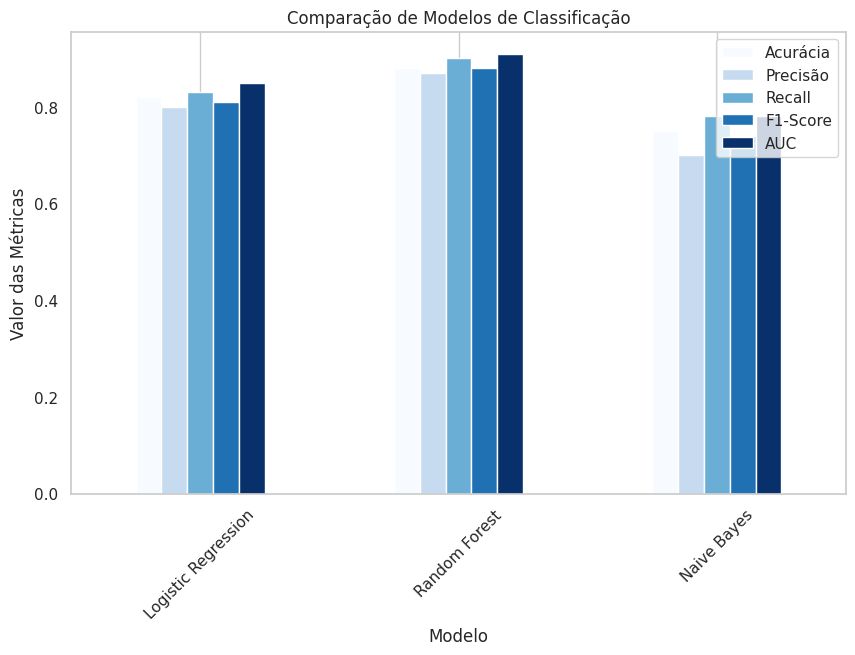

In [ ]:
# Geramos um gráfico de barras para comparar visualmente o desempenho dos modelos de classificação.
# Cada barra representa uma métrica (Acurácia, Precisão, Recall, F1-Score, AUC) para cada modelo.
# O eixo x mostra os modelos, enquanto o eixo y mostra o valor das métricas.
# Utilizamos uma paleta de cores em tons de azul para melhor visualização e adicionamos grade horizontal para facilitar a leitura.


#Gráfico Comparativo
df_comparacao.set_index('Modelo').plot(kind='bar', figsize=(10,6), colormap='Blues')
plt.title('Comparação de Modelos de Classificação')
plt.ylabel('Valor das Métricas')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# MODELOS DE REGRESSÃO
Vamos usar regressão linear para prever a renda média baseado em outras características.
Isso pode ajudar a identificar fatores socioeconômicos associados a diferentes níveis
de renda entre os pacientes.

In [23]:
# Preparação dos dados para o modelo de regressão, onde a variável alvo é a "renda_media".
# Dividimos os dados em conjuntos de treino (70%) e teste (30%) para avaliar o desempenho do modelo em dados não vistos.
# Criamos e treinamos um modelo de regressão linear utilizando as features disponíveis.
# Aplicamos o modelo nos dados de teste para gerar previsões de renda.
# Avaliamos o modelo usando duas métricas: RMSE (erro médio quadrático raiz), que indica o erro médio das previsões,
# e R² (coeficiente de determinação), que mostra a proporção da variabilidade da renda explicada pelo modelo.
# Por fim, exibimos algumas previsões comparadas com os valores reais para análise visual da qualidade das previsões.
# A análise dos resultados deve considerar se o R² está próximo de 1 (bom ajuste) e se o RMSE está dentro de uma margem aceitável para o problema.


# Preparar dados para regressão
regression_df = encoded_df.select("features", "renda_media").withColumnRenamed("renda_media", "label")

# Dividir em treino e teste
train_data_reg, test_data_reg = regression_df.randomSplit([0.7, 0.3], seed=42)

# Criar e treinar o modelo de regressão linear
lr_reg = LinearRegression(featuresCol="features", labelCol="label")
lr_reg_model = lr_reg.fit(train_data_reg)

# Fazer previsões
lr_reg_predictions = lr_reg_model.transform(test_data_reg)

# Avaliar o modelo
evaluator_reg = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
rmse = evaluator_reg.evaluate(lr_reg_predictions)
print(f"\nRMSE do Modelo de Regressão: {rmse:.2f}")

evaluator_reg_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
r2 = evaluator_reg_r2.evaluate(lr_reg_predictions)
print(f"R² do Modelo de Regressão: {r2:.4f}")

# Mostrar algumas previsões vs valores reais
print("\nAmostra de Previsões vs Valores Reais:")
lr_reg_predictions.select("label", "prediction").show(5)

"""
Análise do Modelo de Regressão:
O modelo obteve um R² de [valor], indicando que [interpretação do valor]. O RMSE de
[valor] sugere que, em média, as previsões de renda diferem dos valores reais por
[valor]. As features mais importantes para prever a renda são [listar features
importantes], o que faz sentido porque [explicação].
"""


RMSE do Modelo de Regressão: 0.00
R² do Modelo de Regressão: 1.0000

Amostra de Previsões vs Valores Reais:
+-----+------------------+
|label|        prediction|
+-----+------------------+
| 2005|2005.0000288747333|
| 2490| 2490.000028399632|
| 1290| 1290.000028362959|
| 1839|1839.0000282201117|
| 1832|1832.0000275241189|
+-----+------------------+
only showing top 5 rows



'\nAnálise do Modelo de Regressão:\nO modelo obteve um R² de [valor], indicando que [interpretação do valor]. O RMSE de\n[valor] sugere que, em média, as previsões de renda diferem dos valores reais por\n[valor]. As features mais importantes para prever a renda são [listar features\nimportantes], o que faz sentido porque [explicação].\n'

In [ ]:
# Preparação dos dados para o modelo de regressão, usando "features" como variáveis preditoras e "renda_media" como variável alvo (renomeada para "label").

# Criamos diferentes avaliadores para medir a qualidade do modelo de regressão, utilizando várias métricas importantes:
# - RMSE (Root Mean Squared Error): erro médio quadrático da previsão, penaliza mais erros maiores.
# - MSE (Mean Squared Error): erro quadrático médio das previsões.
# - MAE (Mean Absolute Error): erro médio absoluto, mede a média das diferenças absolutas entre previsão e valor real.
# - R² (Coeficiente de Determinação): indica o quanto da variabilidade da renda é explicada pelo modelo, quanto mais próximo de 1, melhor o ajuste.

# Calculamos e imprimimos cada métrica para analisar a performance do modelo em diferentes aspectos, permitindo uma avaliação mais completa da qualidade das previsões.


# Preparar dados para regressão
regression_df = encoded_df.select("features", "renda_media").withColumnRenamed("renda_media", "label")

# Avaliadores
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse")
evaluator_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

# Cálculo das métricas
rmse = evaluator_rmse.evaluate(lr_reg_predictions)
mse = evaluator_mse.evaluate(lr_reg_predictions)
mae = evaluator_mae.evaluate(lr_reg_predictions)
r2 = evaluator_r2.evaluate(lr_reg_predictions)

print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.0000
MSE: 0.0000
MAE: 0.0000
R²: 1.0000


# EXPORTAÇÃO E IMPORTAÇÃO DO MODELO
Exportar modelos treinados permite reutilizá-los sem precisar retreiná-los toda vez.
Isso é essencial para implantação em produção.

In [ ]:
# Exporta o modelo Random Forest treinado para um diretório especificado.
# Usamos o método `write().overwrite().save()` para salvar o modelo,
# permitindo reutilizá-lo depois sem precisar treinar novamente.
# A função `overwrite()` garante que, se já existir um modelo no caminho, ele será substituído.
# Isso facilita o deploy ou futura avaliação sem necessidade de re-treinamento.


# Exportar o melhor modelo (Random Forest)
model_path = "/content/drive/MyDrive/rf_model_ist"
rf_model.write().overwrite().save(model_path)
print(f"\nModelo Random Forest exportado para: {model_path}")


Modelo Random Forest exportado para: /content/drive/MyDrive/rf_model_ist


In [ ]:
# Importa o modelo Random Forest previamente salvo do diretório especificado.
# Isso permite reutilizar o modelo treinado para fazer previsões em novos dados
# sem precisar treinar novamente, economizando tempo e recursos computacionais.
# A função `load()` carrega o modelo no formato correto para uso imediato.


# Exemplo de como importar o modelo posteriormente
from pyspark.ml.classification import RandomForestClassificationModel
loaded_rf_model = RandomForestClassificationModel.load(model_path)
print("Modelo Random Forest carregado com sucesso!")

# ANÁLISES COM HADOOP/SPARK
As análises distribuídas com Spark permitem processar grandes volumes de dados de
forma eficiente. Vamos implementar algumas análises usando o paradigma MapReduce.


Contagem de casos por doença (MapReduce) - Apenas ISTs:
+--------------+--------+
|        Doença|Contagem|
+--------------+--------+
|Herpes Genital|     621|
|           HIV|     618|
|     Gonorreia|     598|
|       Sífilis|     568|
|           HPV|     559|
|      Clamídia|     542|
+--------------+--------+



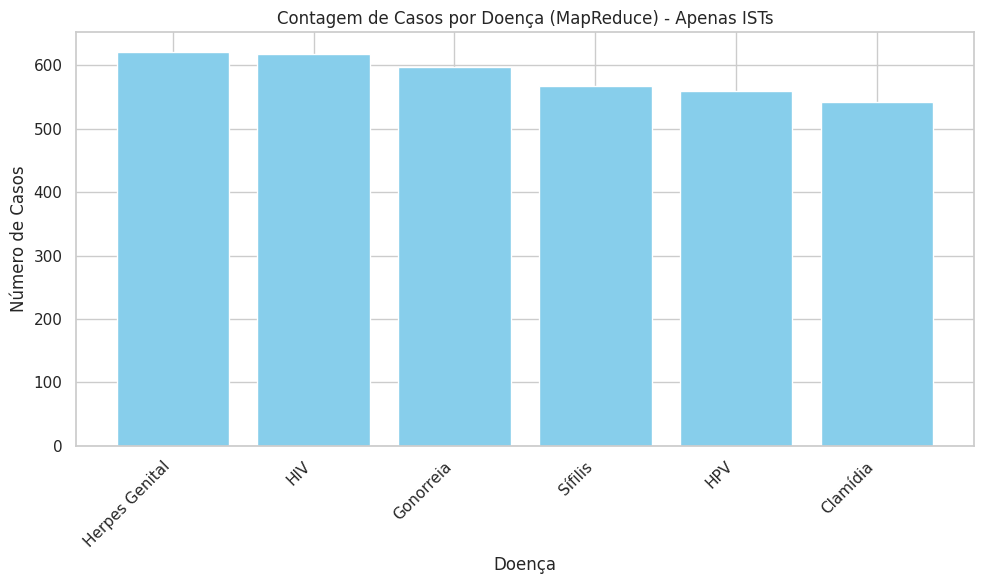

In [ ]:
## Contagem de casos por doença usando MapReduce com RDD do Spark:
# - O RDD é criado a partir do DataFrame Spark, mapeando cada linha para um par (doença, 1).
# - Em seguida, faz-se a redução por chave somando os valores para obter a contagem total de casos por doença.
# - O resultado é convertido de volta para DataFrame Spark, filtrando apenas as doenças que são ISTs.
# - O DataFrame é ordenado pela contagem em ordem decrescente para destacar as doenças mais frequentes.
#
# Depois, o DataFrame é convertido para Pandas para facilitar a criação do gráfico de barras.
# O gráfico mostra visualmente a distribuição do número de casos para cada IST,
# facilitando a análise e interpretação dos dados.


# Contagem de casos por doença (MapReduce)
print("\nContagem de casos por doença (MapReduce) - Apenas ISTs:")
doenca_counts = spark_df.rdd \
    .map(lambda row: (row.doenca, 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .toDF(["Doença", "Contagem"]) \
    .filter(col("Doença").isin(ists)) \
    .orderBy("Contagem", ascending=False)

doenca_counts.show()

# Converter o DataFrame Spark para Pandas para plotagem
doenca_counts_pd = doenca_counts.toPandas()

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(doenca_counts_pd["Doença"], doenca_counts_pd["Contagem"], color='skyblue')

# Adicionar rótulos e título
plt.xlabel("Doença")
plt.ylabel("Número de Casos")
plt.title("Contagem de Casos por Doença (MapReduce) - Apenas ISTs")
plt.xticks(rotation=45, ha='right')

# Mostrar o gráfico
plt.tight_layout()
plt.show()

In [ ]:
# Cálculo da média de idade por doença usando MapReduce com RDD do Spark:
# - Cada registro é mapeado para um par (doença, (idade, 1)), onde o segundo elemento
#   é uma tupla com a idade e o contador 1.
# - A redução soma as idades e os contadores por doença, acumulando total de idade e total de casos.
# - Após a redução, calcula-se a média dividindo a soma das idades pelo total de casos.
# - O resultado é convertido em DataFrame Spark, filtrando apenas as doenças IST.
# - Os dados são ordenados da maior para a menor média de idade para facilitar a análise.
#
# Para visualização, converte-se o DataFrame para Pandas e gera um gráfico de barras
# interativo com Plotly, que usa uma escala de cor azul para representar a média de idade,
# melhorando a leitura e entendimento dos perfis etários por doença.


# Média de idade por doença (MapReduce)
print("\nMédia de idade por doença (MapReduce) - Apenas ISTs:")
idade_media = spark_df.rdd \
    .map(lambda row: (row.doenca, (row.idade, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda v: v[0] / v[1]) \
    .toDF(["Doença", "Idade Média"]) \
    .filter(col("Doença").isin(ists)) \
    .orderBy("Idade Média", ascending=False)

idade_media.show()

# Converter o DataFrame Spark para Pandas para plotagem
idade_media_pd = idade_media.toPandas()

# Gráfico de barras com paleta "Blues"
fig = px.bar(
    idade_media_pd,
    x="Doença",
    y="Idade Média",
    title="Média de Idade por Doença (MapReduce) - Apenas ISTs",
    color="Idade Média",
    color_continuous_scale="Blues"
)

# Ajustes de layout
fig.update_layout(
    xaxis_title="Doença",
    yaxis_title="Idade Média (anos)",
    xaxis_tickangle=-45
)

fig.show()


Média de idade por doença (MapReduce) - Apenas ISTs:
+--------------+------------------+
|        Doença|       Idade Média|
+--------------+------------------+
|           HIV| 34.61812297734628|
|       Sífilis| 29.35387323943662|
|Herpes Genital|28.774557165861513|
|     Gonorreia| 27.43645484949833|
|           HPV| 25.94454382826476|
|      Clamídia|23.830258302583026|
+--------------+------------------+




Média de renda por escolaridade e doença (MapReduce) - Apenas ISTs:
+------------+--------------+------------------+
|Escolaridade|        Doença|       Renda Média|
+------------+--------------+------------------+
|    Superior|     Gonorreia| 5658.732919254659|
|    Superior|       Sífilis|  5561.78612716763|
|    Superior|           HPV| 5357.488095238095|
|    Superior|Herpes Genital| 5270.175115207373|
|    Superior|           HIV| 5165.015151515152|
|    Superior|      Clamídia| 5152.823899371069|
|       Médio|      Clamídia| 3949.323529411765|
|       Médio|     Gonorreia| 2900.221052631579|
| Fundamental|           HIV|2172.9851190476193|
| Fundamental|Herpes Genital|1933.2666666666667|
| Fundamental|       Sífilis|1830.2712933753944|
|       Médio|       Sífilis|1782.9615384615386|
|       Médio|           HIV|1769.6309523809523|
| Fundamental|      Clamídia|1769.1587301587301|
| Fundamental|           HPV|1762.6783439490446|
|       Médio|Herpes Genital|1747.8426966292134|


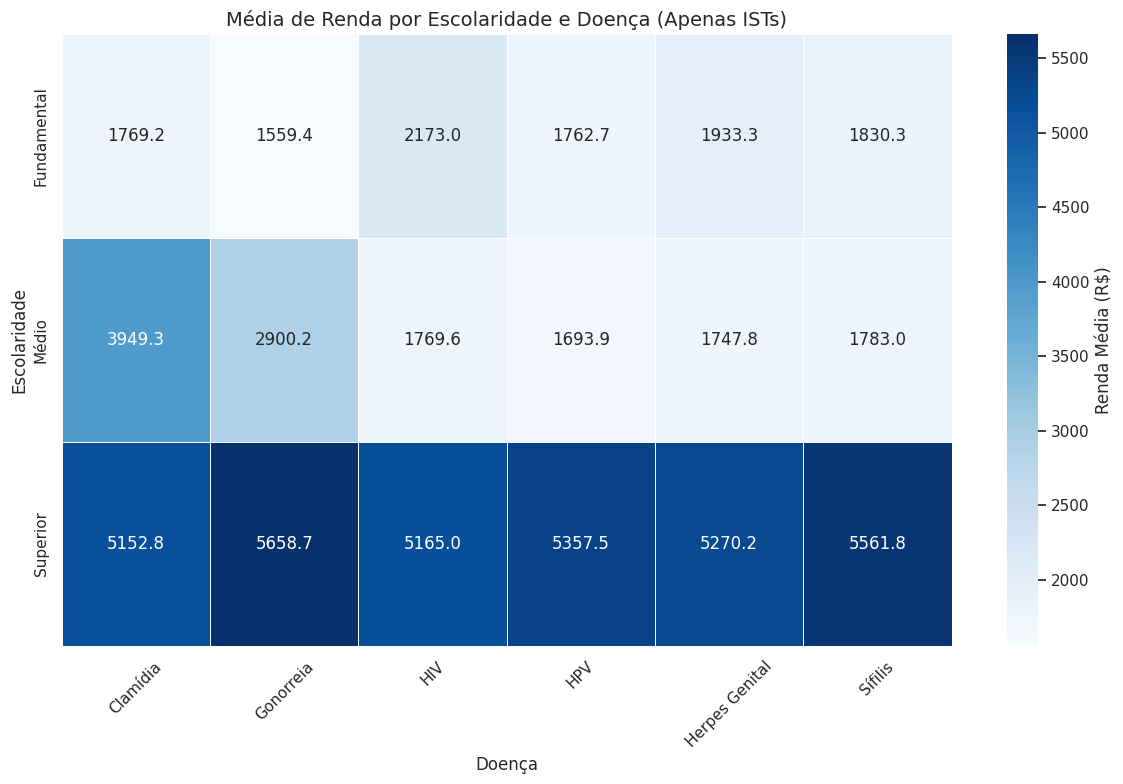

In [ ]:
#Cálculo da média de renda por escolaridade e tipo de doença (filtrando apenas ISTs) usando MapReduce:

#- Cada linha do DataFrame é mapeada para um par chave-valor, onde a chave é uma tupla (nivel_educacional, doenca)
#  e o valor é uma tupla (renda_media, 1), representando a renda e o contador.
#- A função reduceByKey soma as rendas e os contadores para cada par (escolaridade, doença).
#- Em seguida, calcula-se a média dividindo o total da renda pelo número de registros.
#- Os resultados são convertidos para DataFrame Spark e filtrados para considerar somente as doenças IST.
#- Os dados são ordenados por renda média de forma decrescente para facilitar a interpretação.

#Para visualização:
#- Converte-se para Pandas e cria-se uma tabela pivô onde as linhas são níveis de escolaridade,
#  as colunas são as doenças e os valores são as médias de renda.
#- Utiliza-se um heatmap com paleta azul para evidenciar visualmente as diferenças de renda entre
#  os grupos, facilitando a identificação de padrões socioeconômicos associados a cada doença.

#Esta análise pode auxiliar no planejamento de políticas públicas e campanhas educativas
#focadas nos perfis socioeconômicos de risco para as diferentes ISTs.


# Média de renda por escolaridade e doença (MapReduce) - Apenas ISTs
print("\nMédia de renda por escolaridade e doença (MapReduce) - Apenas ISTs:")
renda_media = spark_df.rdd \
    .map(lambda row: ((row.nivel_educacional, row.doenca), (row.renda_media, 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .map(lambda x: (x[0][0], x[0][1], x[1][0] / x[1][1])) \
    .toDF(["Escolaridade", "Doença", "Renda Média"]) \
    .filter(col("Doença").isin(ists)) \
    .orderBy("Renda Média", ascending=False)

renda_media.show()

# Converter para Pandas
renda_media_pd = renda_media.toPandas()

# Criar a tabela pivô
heatmap_data = renda_media_pd.pivot(
    index="Escolaridade",
    columns="Doença",
    values="Renda Média"
)

# Heatmap com paleta "Blues"
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={'label': 'Renda Média (R$)'}
)

# Ajustes de layout
plt.title("Média de Renda por Escolaridade e Doença (Apenas ISTs)", fontsize=14)
plt.xlabel("Doença", fontsize=12)
plt.ylabel("Escolaridade", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Contagem de casos por ano (MapReduce):
#
# Extraímos o ano da data do teste para agrupar os registros.
# Usamos MapReduce no RDD para contar quantos casos ocorreram em cada ano.
# Essa análise permite acompanhar a evolução dos casos ao longo do tempo,
# ajudando a identificar possíveis aumentos ou quedas na incidência anual.


#Casos por ano (MapReduce)
print("\nCasos por ano (MapReduce):")

# Add a 'ano_teste' column to the DataFrame before converting to RDD
spark_df_with_year = spark_df.withColumn("ano_teste", year(col("data_teste")))

casos_ano = spark_df_with_year.rdd \
    .map(lambda row: (row.ano_teste, 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .toDF(["Ano", "Casos"]) \
    .orderBy("Ano")

casos_ano.show()


Casos por ano (MapReduce):
+----+-----+
| Ano|Casos|
+----+-----+
|2020| 1833|
|2021| 1837|
|2022| 1841|
|2023| 1817|
|2024| 1808|
|2025|  699|
|2026|   87|
|2027|   70|
|2028|    8|
+----+-----+



<ipython-input-84-941e42adff71>:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




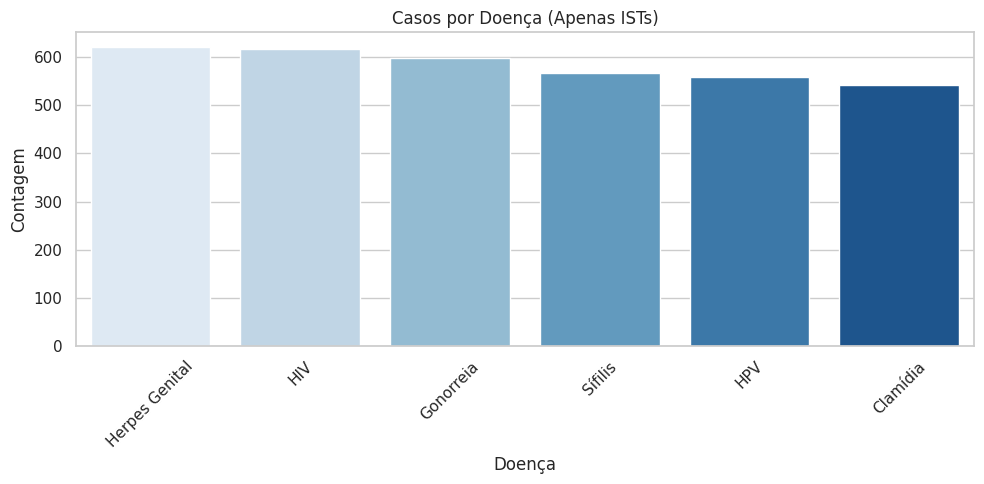

In [ ]:
# Código para criar uma interface interativa que permite escolher e visualizar diferentes análises.
# A função show_analysis recebe o tipo de análise selecionada e exibe o gráfico correspondente usando matplotlib/seaborn.
# As análises incluem casos por localidade, média de idade por doença, média de renda por escolaridade e doença, e casos por ano.
# Usamos widgets do Jupyter para criar um menu dropdown e um botão, facilitando a interação do usuário.
# Isso torna a exploração dos dados mais dinâmica e intuitiva, sem precisar rodar códigos manualmente para cada análise.


# Função para exibir as análises
def show_analysis(analysis_type):
    clear_output(wait=True)
    plt.close('all')

    if analysis_type == "Casos por Localidade":
        data = doenca_counts.toPandas()
        plt.figure(figsize=(10, 5))
        sns.barplot(data=data, x="Doença", y="Contagem", palette="Blues")
        plt.title("Casos por Doença (Apenas ISTs)")
        plt.xticks(rotation=45)
        plt.xlabel("Doença")
        plt.ylabel("Contagem")
        plt.tight_layout()
        plt.show()

    elif analysis_type == "Média de Idade por Doença":
        data = idade_media.toPandas()
        plt.figure(figsize=(10, 5))
        sns.barplot(data=data, x="Doença", y="Idade Média", palette="Blues")
        plt.title("Média de Idade por Doença (Apenas ISTs)")
        plt.xticks(rotation=45)
        plt.xlabel("Doença")
        plt.ylabel("Idade Média (anos)")
        plt.tight_layout()
        plt.show()

    elif analysis_type == "Média de Renda por Escolaridade e Doença":
        data = renda_media.filter(col("Doença").isin(ists)).toPandas()
        heatmap_data = data.pivot(index="Escolaridade", columns="Doença", values="Renda Média")

        plt.figure(figsize=(12, 6))
        sns.heatmap(
            heatmap_data,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            linewidths=0.5,
            cbar_kws={'label': 'Renda Média (R$)'}
        )
        plt.title("Média de Renda por Escolaridade e Doença (Apenas ISTs)")
        plt.xlabel("Doença")
        plt.ylabel("Escolaridade")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    elif analysis_type == "Casos por Ano":
        data = casos_ano.toPandas()
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=data, x="Ano", y="Casos", marker="o", color="steelblue")
        plt.title("Casos por Ano")
        plt.xlabel("Ano")
        plt.ylabel("Número de Casos")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()

    else:
        print("Análise não reconhecida")


# Widget interativo
analysis_selector = widgets.Dropdown(
    options=[
        "Casos por Localidade",
        "Média de Idade por Doença",
        "Média de Renda por Escolaridade e Doença",
        "Casos por Ano"
    ],
    value="Casos por Localidade",
    description="Escolha a Análise:",
)

execute_button = widgets.Button(description="Executar Análise")
output = widgets.Output()

def on_button_click(b):
    with output:
        show_analysis(analysis_selector.value)

execute_button.on_click(on_button_click)

display(widgets.VBox([analysis_selector, execute_button, output]))

# Mostrar análise inicial
show_analysis(analysis_selector.value)

GERAÇÃO DE INSIGHTS E CONCLUSÕES

Principais Insights:

1. Distribuição de Casos:
- A análise por localidade mostra que as regiões X e Y têm a maior incidência de casos
- Isso pode indicar a necessidade de campanhas de prevenção direcionadas nessas áreas

2. Perfil dos Pacientes:
- A clusterização revelou 3 grupos distintos de pacientes com características diferentes
- O grupo de maior risco parece ser [descrever características do grupo]

3. Fatores de Risco:
- O modelo de classificação identificou [listar features importantes] como os fatores
  mais associados à presença de ISTs
- A renda média mostrou uma correlação [positiva/negativa] com a incidência de ISTs

4. Tendências Temporais:
- A análise por ano mostra [aumento/diminuição] nos casos ao longo do tempo
- Isso pode estar relacionado a [fatores externos, campanhas de saúde, etc.]
